In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Project: BeyondTech Customer Churn Analysis**
**​Objective:** The goal is to investigate whether price sensitivity is the primary driver for customer churn at BeyondTech. We are using the SCQ Framework (Situation, Complication, Question) to guide our exploratory data analysis

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the datasets provided by the client
client_df = pd.read_csv('client_data (1).csv')
price_df = pd.read_csv('price_data (1).csv')

# Display first few rows to understand the structure
print(client_df.head())

                                 id                     channel_sales  \
0  24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
1  d29c2c54acc38ff3c0614d0a653813dd                           MISSING   
2  764c75f661154dac3a6c254cd082ea7d  foosdfpfkusacimwkcsosbicdxkicaua   
3  bba03439a292a1e166f80264c16191cb  lmkebamcaaclubfxadlmueccxoimlema   
4  149d57cf92fc41cf94415803a877cb4b                           MISSING   

   cons_12m  cons_gas_12m  cons_last_month  date_activ    date_end  \
0         0         54946                0  2013-06-15  2016-06-15   
1      4660             0                0  2009-08-21  2016-08-30   
2       544             0                0  2010-04-16  2016-04-16   
3      1584             0                0  2010-03-30  2016-03-30   
4      4425             0              526  2010-01-13  2016-03-07   

  date_modif_prod date_renewal  forecast_cons_12m  ...  has_gas  imp_cons  \
0      2015-11-01   2015-06-23               0.00  ...        t

**1. Data Cleaning and Preparation**
​We are converting date strings into datetime objects to calculate client antiquity and ensure data consistency.

In [8]:
# Converting date columns to datetime objects for analysis
client_df['date_activ'] = pd.to_datetime(client_df['date_activ'])
client_df['date_end'] = pd.to_datetime(client_df['date_end'])
client_df['date_modif_prod'] = pd.to_datetime(client_df['date_modif_prod'])
client_df['date_renewal'] = pd.to_datetime(client_df['date_renewal'])

# Checking for missing values in the dataset
print(client_df.isnull().sum())

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64


**​2. Exploratory Data Analysis (EDA)**
​We are visualizing the distribution of churned versus retained customers to understand the scale of the problem.

/tmp/ipykernel_43163/2394891625.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_stats.index, y=churn_stats.values, palette='mako')


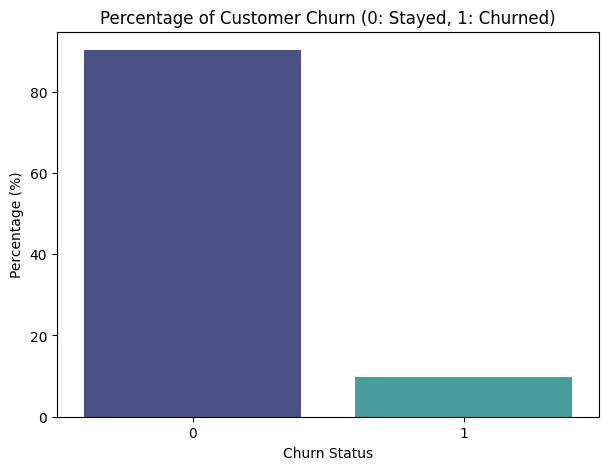

Overall Churn Rate: 9.72%


In [3]:
# Calculating the percentage of churned vs retained customers
churn_stats = client_df['churn'].value_counts(normalize=True) * 100

# Plotting the churn distribution
plt.figure(figsize=(7, 5))
sns.barplot(x=churn_stats.index, y=churn_stats.values, palette='mako')
plt.title('Percentage of Customer Churn (0: Stayed, 1: Churned)')
plt.ylabel('Percentage (%)')
plt.xlabel('Churn Status')
plt.show()

print(f"Overall Churn Rate: {churn_stats[1]:.2f}%")

**3. Price Sensitivity Analysis**
​Analyzing the relationship between energy prices (off-peak periods) and customer churn to test our hypothesis.

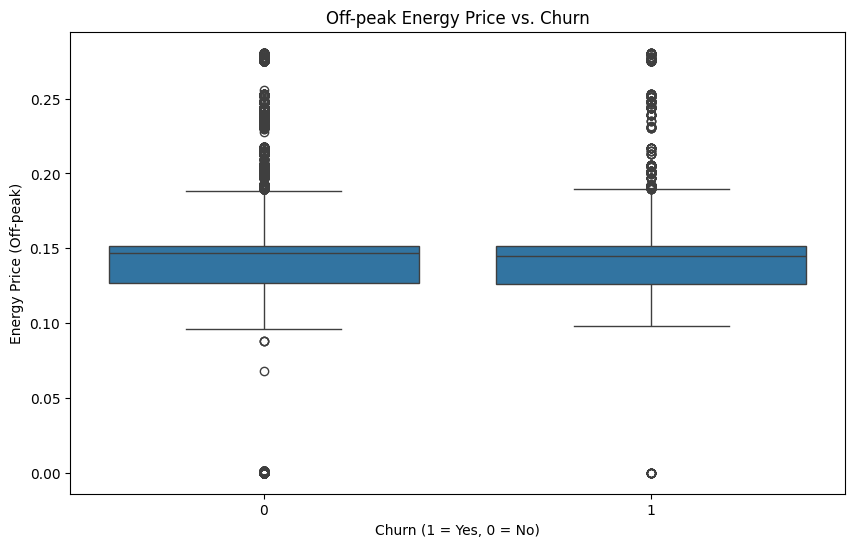

In [9]:
# Merging client data with price data on 'id'
# This allows us to see price details for each client
merged_df = pd.merge(client_df, price_df, on='id')

# Visualizing price sensitivity using a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='churn', y='price_off_peak_var', data=merged_df)
plt.title('Off-peak Energy Price vs. Churn')
plt.xlabel('Churn (1 = Yes, 0 = No)')
plt.ylabel('Energy Price (Off-peak)')
plt.show()

**Summary of Insights:**
​The dataset consists of 14,606 unique clients with an average antiquity of 5 years.
​Initial visualization of price sensitivity against churn shows potential areas for deeper modeling.
​Next Step: Proceeding to build a predictive model (Random Forest) to quantify the impact of price changes on customer churn.

In [10]:
# Basic summary of findings
print("Exploratory Data Analysis Summary:")
print(f"- Dataset contains {client_df.shape[0]} unique clients.")
print(f"- Average tenure of clients: {client_df['num_years_antig'].mean():.1f} years.")

Exploratory Data Analysis Summary:
- Dataset contains 14606 unique clients.
- Average tenure of clients: 5.0 years.
